# Tactical Backtest
Answers: **did the trim/exit rules add value vs holding to actual exit date?**

Set the ticker, entry/exit dates and position size below. Run all cells.

#### Imports and Policy Load

In [64]:
# Imports and policy load
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import geoquant.configs.config as config
import geoquant.data_io as data_io
import geoquant.indicators as indicators
from geoquant.decision_policy import load_decision_policy

importlib.reload(data_io)
importlib.reload(indicators)

policy = load_decision_policy()
rules = policy['rules']
print('Policy loaded')


Policy loaded


#### Trade Parameters

In [65]:
# Trade parameters
# ── TRADE PARAMETERS ── edit these for each backtest ──────────────────────────
TICKER        = 'SLVR.LSE'       # IBKR ticker
CCY           = 'GBP'            # local currency (COPA trades in USD on LSE)
GBX           = False            # True if LSE penny stock (price in pence)
ENTRY_DATE    = '20/11/2025'     # DD/MM/YYYY
EXIT_DATE     = '30/04/2026'     # DD/MM/YYYY
ENTRY_SHARES  = 40               # shares at entry
ENTRY_PRICE   = None             # actual IBKR fill price (None = use first close from data)
TRIM_FRACTION = .5             # fraction to sell on trim signal (used in trim mode)

# Extra tactical rule used by trim mode: trim if intraday high exceeds entry by this percent
ENTRY_SPIKE_TRIM_PCT = 0.08      # +8% from entry

# Parse once — used everywhere below
ENTRY_TS = pd.to_datetime(ENTRY_DATE, dayfirst=True)
EXIT_TS  = pd.to_datetime(EXIT_DATE,  dayfirst=True)

# Rule thresholds (pulled from policy but can override here for testing)
TRIM_THRESHOLD_5D = rules['trim']['tactical_spike_5d']['threshold_return_5d']
TRIM_THRESHOLD_3D = rules['trim']['tactical_spike_3d']['threshold_return_3d']
ATR_STOP_MULT     = rules['exit']['hard_stop_multiple_atr']
ATR_WINDOW        = 14

# Costs
FEE_BPS        = policy['backtest']['costs']['fee_bps_per_trade']
SLIP_BPS       = policy['backtest']['costs']['slippage_bps_per_trade']
COST_PER_TRADE = (FEE_BPS + SLIP_BPS) / 10000

print(f'Backtest: {TICKER} ({CCY})  {ENTRY_TS.strftime("%d/%m/%Y")} -> {EXIT_TS.strftime("%d/%m/%Y")}')
print(f'Entry price override: {ENTRY_PRICE if ENTRY_PRICE else "none - will use first close"}')
print(f'Trim threshold: 3d>{TRIM_THRESHOLD_3D:.0%}  5d>{TRIM_THRESHOLD_5D:.0%}')
print(f'Entry-spike trim threshold (trim mode): +{ENTRY_SPIKE_TRIM_PCT:.0%} intraday from entry')
print(f'ATR stop: {ATR_STOP_MULT}x  |  cost/trade: {COST_PER_TRADE:.2%}')


Backtest: SLVR.LSE (GBP)  20/11/2025 -> 30/04/2026
Entry price override: none - will use first close
Trim threshold: 3d>20%  5d>25%
Entry-spike trim threshold (trim mode): +8% intraday from entry
ATR stop: 2.5x  |  cost/trade: 0.08%


#### Price Fetch

In [66]:
# Price fetch
# ── FETCH PRICES ──────────────────────────────────────────────────────────────
fetch_params = dict(config.data_params)
fetch_params['start'] = ENTRY_TS - pd.Timedelta(days=30)  # warm-up for ATR
fetch_params['end']   = EXIT_TS

raw = data_io.fetch_csv(TICKER, fetch_params)
raw = raw.loc[fetch_params['start']:fetch_params['end']]

if GBX:
    raw[['Open','High','Low','Close']] /= 100.0

print(f'Fetched {len(raw)} rows  {raw.index[0].strftime("%d/%m/%Y")} → {raw.index[-1].strftime("%d/%m/%Y")}')
raw.tail(3)

Fetched 133 rows  21/10/2025 → 30/04/2026


,Open,High,Low,Close,Volume
Date,,,,,
2026-04-28,60.02,60.24,58.97,59.580,6006
2026-04-29,60.13,60.20,58.45,58.660,11982
2026-04-30,59.70,60.47,59.70,60.075,1391


#### Signal Construction

In [67]:
# Signal construction
# ── COMPUTE SIGNALS ───────────────────────────────────────────────────────────
df = raw[['Open','High','Low','Close']].copy()

df['ATR'] = indicators.compute_atr(df, ATR_WINDOW)

# Rolling returns (close-based)
df['ret_3d'] = df['Close'].pct_change(3)
df['ret_5d'] = df['Close'].pct_change(5)

# Close-based trim trigger (conservative)
df['trim_signal_close'] = (
    (df['ret_5d'] >= TRIM_THRESHOLD_5D) |
    (df['ret_3d'] >= TRIM_THRESHOLD_3D)
)

# Intraday touch trim trigger (optimistic/base)
df['trim_level_3d'] = df['Close'].shift(3) * (1 + TRIM_THRESHOLD_3D)
df['trim_level_5d'] = df['Close'].shift(5) * (1 + TRIM_THRESHOLD_5D)
df['trim_touch_3d'] = df['High'] >= df['trim_level_3d']
df['trim_touch_5d'] = df['High'] >= df['trim_level_5d']
df['trim_signal_touch'] = df['trim_touch_3d'] | df['trim_touch_5d']

# Limit to trade window only
df = df.loc[ENTRY_TS:EXIT_TS].copy()
data_open_price = df['Close'].iloc[0]
entry_price = ENTRY_PRICE if ENTRY_PRICE is not None else data_open_price

# Explicit entry-based intraday spike rule (captures "up +8% then red close" days)
df['trim_level_entry'] = entry_price * (1 + ENTRY_SPIKE_TRIM_PCT)
df['trim_touch_entry'] = df['High'] >= df['trim_level_entry']

print(f'Entry price (IBKR fill): {entry_price:.4f}  |  first close in data: {data_open_price:.4f}')
print(f'Rows in trade window: {len(df)}')
print(f'Entry-spike intraday touches: {int(df["trim_touch_entry"].sum())}')


Entry price (IBKR fill): 41.8300  |  first close in data: 41.8300
Rows in trade window: 111
Entry-spike intraday touches: 105


#### Scenario Simulation Engine

In [68]:
def run_scenario(
    df_in: pd.DataFrame,
    trim_mode: str,        # 'none' | 'touch' | 'close'
    extra_slip_bps: float,
):
    shares = float(ENTRY_SHARES)
    cash = 0.0
    trades = []
    extra_cost = extra_slip_bps / 10000

    atr_at_entry = df_in['ATR'].iloc[0]
    stop_price = entry_price - ATR_STOP_MULT * atr_at_entry

    for date, row in df_in.iterrows():
        close_px = row['Close']
        high_px = row['High']
        atr = row['ATR']

        # ATR stop ratchets up (never down)
        new_stop = close_px - ATR_STOP_MULT * atr
        stop_price = max(stop_price, new_stop)

        # Stop check: close-based trigger/fill
        if close_px <= stop_price and shares > 0:
            exec_px = close_px
            proceeds = shares * exec_px * (1 - COST_PER_TRADE - extra_cost)
            pnl_value = proceeds - shares * entry_price
            cash += proceeds
            trades.append({
                'date': date, 'action': 'stop_exit', 'shares': shares,
                'price': exec_px, 'stop': stop_price,
                'reason': 'atr_stop_exit',
                'pnl': pnl_value, 'pnl_pct': pnl_value / (shares * entry_price),
            })
            shares = 0
            break

        if shares <= 0 or trim_mode == 'none':
            continue

        # Trim logic (comparison scenarios only — not the base policy)
        trim_triggered = False
        exec_px = close_px
        trim_reason = 'close_signal'

        if trim_mode == 'touch':
            levels = []
            if bool(row['trim_touch_entry']) and pd.notna(row['trim_level_entry']):
                levels.append(('entry_spike', row['trim_level_entry']))
            if bool(row['trim_touch_3d']) and pd.notna(row['trim_level_3d']):
                levels.append(('touch_3d', row['trim_level_3d']))
            if bool(row['trim_touch_5d']) and pd.notna(row['trim_level_5d']):
                levels.append(('touch_5d', row['trim_level_5d']))

            if levels:
                trim_triggered = True
                trim_reason, exec_px = min(levels, key=lambda x: x[1])
        else:  # 'close'
            if bool(row['trim_signal_close']):
                trim_triggered = True
                exec_px = close_px
                trim_reason = 'close_signal'

        if trim_triggered:
            trim_shares = shares * TRIM_FRACTION
            proceeds = trim_shares * exec_px * (1 - COST_PER_TRADE - extra_cost)
            pnl_value = proceeds - trim_shares * entry_price
            cash += proceeds
            shares -= trim_shares
            trades.append({
                'date': date, 'action': 'trim', 'shares': trim_shares,
                'price': exec_px, 'stop': np.nan, 'reason': trim_reason,
                'pnl': pnl_value, 'pnl_pct': pnl_value / (trim_shares * entry_price),
            })

    if shares > 0:
        exit_price = df_in['Close'].iloc[-1]
        proceeds = shares * exit_price * (1 - COST_PER_TRADE - extra_cost)
        pnl_value = proceeds - shares * entry_price
        cash += proceeds
        trades.append({
            'date': df_in.index[-1], 'action': 'final_exit', 'shares': shares,
            'price': exit_price, 'stop': np.nan, 'reason': 'final_exit',
            'pnl': pnl_value, 'pnl_pct': pnl_value / (shares * entry_price),
        })

    trade_log_local = pd.DataFrame(trades)
    total_cost = ENTRY_SHARES * entry_price
    pnl = cash - total_cost
    pct = pnl / total_cost
    return pnl, pct, trade_log_local


In [69]:
# --- SCENARIO SIMULATION ---
# BASE = ATR stop only (the agreed policy — no trims).
# Trim scenarios are comparisons against that baseline.
SCENARIOS = {
    'atr_only': {                    # BASE — policy as agreed
        'trim_mode': 'none', 'extra_slip_bps': 0.0,
    },
    'optimistic_touch_trim': {       # trim fired at intraday touch, no extra slippage
        'trim_mode': 'touch', 'extra_slip_bps': 0.0,
    },
    'base_touch_trim': {             # trim fired at intraday touch, +20bps slippage
        'trim_mode': 'touch', 'extra_slip_bps': 20.0,
    },
    'conservative_close_trim': {     # trim fired at close-of-day, no extra slippage
        'trim_mode': 'close', 'extra_slip_bps': 0.0,
    },
}

_EVENT_LABELS = {
    ('trim',       'entry_spike'):  'TRIM  — entry spike',
    ('trim',       'touch_3d'):     'TRIM  — 3d return touch',
    ('trim',       'touch_5d'):     'TRIM  — 5d return touch',
    ('trim',       'close_signal'): 'TRIM  — close signal',
    ('stop_exit',  'atr_stop_exit'):'ATR STOP EXIT',
    ('final_exit', 'final_exit'):   'HELD to exit date',
}

def _label(row):
    return _EVENT_LABELS.get((row['action'], row['reason']), f"{row['action']} / {row['reason']}")

scenario_rows = []
scenario_trade_logs = {}
for name, cfg in SCENARIOS.items():
    pnl, pct, tlog = run_scenario(
        df,
        cfg['trim_mode'],
        cfg['extra_slip_bps'],
    )
    scenario_rows.append({
        'scenario': name,
        'trim_mode': cfg['trim_mode'],
        'extra_slip_bps': cfg['extra_slip_bps'],
        'pnl': pnl,
        'return_pct': pct,
        'trades': len(tlog),
    })
    scenario_trade_logs[name] = tlog

scenario_results = pd.DataFrame(scenario_rows).sort_values('return_pct', ascending=False)

print('SCENARIO COMPARISON  (base = atr_only)')
print(
    scenario_results[['scenario', 'return_pct', 'pnl', 'trades', 'trim_mode', 'extra_slip_bps']]
    .to_string(
        index=False,
        formatters={'return_pct': '{:+.2%}'.format, 'pnl': '{:+.2f}'.format},
    )
)

# Base scenario = ATR only (no trims)
trade_log = scenario_trade_logs['atr_only']
with_rules_pnl = float(scenario_results.loc[scenario_results['scenario'] == 'atr_only', 'pnl'].iloc[0])
with_rules_pct = float(scenario_results.loc[scenario_results['scenario'] == 'atr_only', 'return_pct'].iloc[0])

# ── TRADE LOG (base scenario: atr_only) ──────────────────────────────────────
print('\nBASE SCENARIO TRADE LOG (atr_only)')
disp = trade_log[['date', 'shares', 'price', 'stop', 'pnl', 'pnl_pct']].copy()
disp.insert(1, 'event', trade_log.apply(_label, axis=1))
print(
    disp.to_string(
        index=False,
        formatters={
            'price':   '{:.4f}'.format,
            'stop':    lambda v: f'{v:.4f}' if pd.notna(v) else '—',
            'pnl':     '{:+.2f}'.format,
            'pnl_pct': '{:+.2%}'.format,
        },
    )
)


SCENARIO COMPARISON  (base = atr_only)
               scenario return_pct      pnl  trades trim_mode  extra_slip_bps
conservative_close_trim   +102.91% +1721.88       2     close             0.0
               atr_only    +84.07% +1406.73       1      none             0.0
  optimistic_touch_trim     +7.91%  +132.41      43     touch             0.0
        base_touch_trim     +7.70%  +128.80      43     touch            20.0

BASE SCENARIO TRADE LOG (atr_only)
      date         event  shares   price    stop      pnl pnl_pct
2026-01-30 ATR STOP EXIT    40.0 77.0600 82.3950 +1406.73 +84.07%


In [70]:
# --- TRIM LOGIC UNIT TEST CELL ---
# This cell tests trim trigger and execution price logic in isolation

def test_trim_logic(df, entry_price, TRIM_FRACTION, ENTRY_SPIKE_TRIM_PCT):
    results = []
    for date, row in df.iterrows():
        trim_triggered = False
        exec_px = None
        trim_reason = None
        levels = []
        # Entry spike trim
        trim_level_entry = entry_price * (1 + ENTRY_SPIKE_TRIM_PCT)
        if bool(row['trim_touch_entry']) and pd.notna(row['trim_level_entry']):
            levels.append(('entry_spike', row['trim_level_entry']))
        if bool(row['trim_touch_3d']) and pd.notna(row['trim_level_3d']):
            levels.append(('touch_3d', row['trim_level_3d']))
        if bool(row['trim_touch_5d']) and pd.notna(row['trim_level_5d']):
            levels.append(('touch_5d', row['trim_level_5d']))
        if levels:
            trim_triggered = True
            trim_reason, exec_px = min(levels, key=lambda x: x[1])
        if trim_triggered:
            results.append({
                'date': date,
                'reason': trim_reason,
                'exec_px': exec_px,
                'high': row['High'],
                'close': row['Close'],
                'trim_level_entry': row['trim_level_entry'],
                'trim_level_3d': row['trim_level_3d'],
                'trim_level_5d': row['trim_level_5d'],
            })
    return pd.DataFrame(results)

# Run the trim logic test and display results
trim_test_results = test_trim_logic(df, entry_price, TRIM_FRACTION, ENTRY_SPIKE_TRIM_PCT)
print('TRIM LOGIC TEST RESULTS:')
print(trim_test_results)


TRIM LOGIC TEST RESULTS:
          date       reason  exec_px   high   close  trim_level_entry  \
0   2025-11-28  entry_spike  45.1764  46.06  46.060           45.1764   
1   2025-12-01  entry_spike  45.1764  48.33  48.285           45.1764   
2   2025-12-02  entry_spike  45.1764  48.27  47.470           45.1764   
3   2025-12-03  entry_spike  45.1764  48.64  48.370           45.1764   
4   2025-12-04  entry_spike  45.1764  47.47  46.980           45.1764   
..         ...          ...      ...    ...     ...               ...   
100 2026-04-24  entry_spike  45.1764  62.43  62.000           45.1764   
101 2026-04-27  entry_spike  45.1764  62.20  61.640           45.1764   
102 2026-04-28  entry_spike  45.1764  60.24  59.580           45.1764   
103 2026-04-29  entry_spike  45.1764  60.20  58.660           45.1764   
104 2026-04-30  entry_spike  45.1764  60.47  60.075           45.1764   

     trim_level_3d  trim_level_5d  
0           50.388       51.18750  
1           52.236       5

#### Buy-and-Hold Baseline Comparison

In [71]:
# Buy-and-hold baseline comparison
# ── SIMULATE: BUY AND HOLD (no rules) + SCENARIO EDGE ────────────────────────
exit_price = df['Close'].iloc[-1]
bah_pnl = (exit_price - entry_price) * ENTRY_SHARES * (1 - COST_PER_TRADE)
bah_pct = bah_pnl / (ENTRY_SHARES * entry_price)
print(f'BUY AND HOLD P&L: {bah_pnl:+.2f}  ({bah_pct:+.2%})')

if 'scenario_results' in globals() and scenario_results is not None:
    scenario_results = scenario_results.copy()
    scenario_results['edge_vs_bah'] = scenario_results['pnl'] - bah_pnl
    scenario_results['edge_vs_bah_pct'] = scenario_results['return_pct'] - bah_pct
    print('\nRULES EDGE VS BUY&HOLD')
    print(
        scenario_results[['scenario', 'return_pct', 'pnl', 'edge_vs_bah_pct', 'edge_vs_bah']]
        .to_string(
            index=False,
            formatters={
                'pnl': '{:+.2f}'.format,
                'return_pct': '{:+.2%}'.format,
                'edge_vs_bah': '{:+.2f}'.format,
                'edge_vs_bah_pct': '{:+.2%}'.format,
            },
        )
    )
    if 'with_rules_pnl' in globals() and 'with_rules_pct' in globals():
        print(f"\nPlot uses atr_only (base): {with_rules_pnl:+.2f}  ({with_rules_pct:+.2%})")
else:
    print("scenario_results is not defined. Please run the scenario simulation cell first.")


BUY AND HOLD P&L: +729.22  (+43.58%)

RULES EDGE VS BUY&HOLD
               scenario return_pct      pnl edge_vs_bah_pct edge_vs_bah
conservative_close_trim   +102.91% +1721.88         +59.33%     +992.67
               atr_only    +84.07% +1406.73         +40.49%     +677.52
  optimistic_touch_trim     +7.91%  +132.41         -35.67%     -596.81
        base_touch_trim     +7.70%  +128.80         -35.88%     -600.42

Plot uses atr_only (base): +1406.73  (+84.07%)


#### Price Chart with Trade Markers

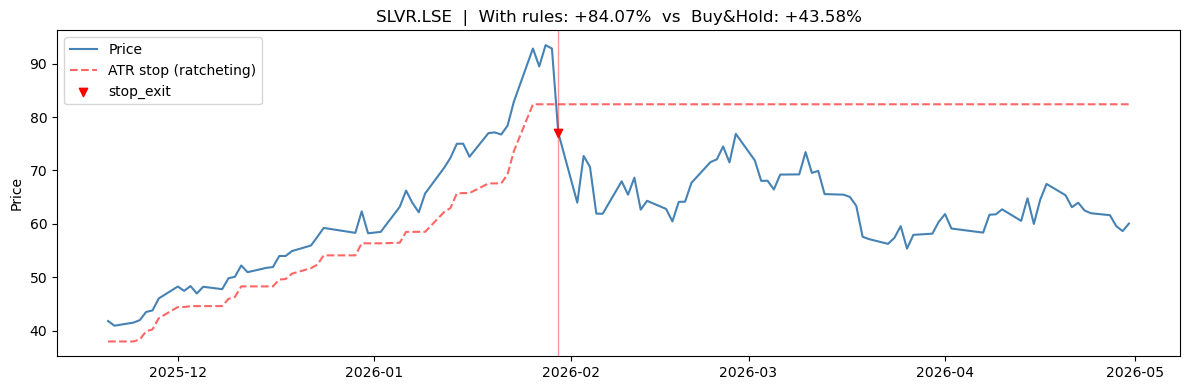

In [72]:
# Price chart with trade markers
# ── EQUITY CURVES ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Price
ax.plot(df.index, df['Close'], color='steelblue', label='Price')

# ATR ratchet stop
initial_stop = entry_price - ATR_STOP_MULT * df['ATR'].iloc[0]
stop_curve = indicators.atr_ratchet_stop(df['Close'], df['ATR'], ATR_STOP_MULT, initial_stop)
ax.plot(df.index, stop_curve, color='red', linestyle='--', alpha=0.6, label='ATR stop (ratcheting)')

# Trade markers
if not trade_log.empty:
    for _, t in trade_log.iterrows():
        color  = 'orange' if t['action'] == 'trim' else 'red'
        marker = 'v'
        ax.axvline(t['date'], color=color, alpha=0.4, linewidth=1)
        ax.scatter(t['date'], t['price'], color=color, marker=marker, zorder=5,
                   label=t['action'] if t['action'] not in [x.get_label() for x in ax.get_lines()] else '')

ax.set_title(f'{TICKER}  |  With rules: {with_rules_pct:+.2%}  vs  Buy&Hold: {bah_pct:+.2%}')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()
plt.show()


#### Book Backtest Runner
Iterates `books.backtest_trades`, runs all scenarios for each trade, and aggregates.

**Interpretation notes / caveats**
- Results are *performance attribution* on trades you actually took — not a forward-looking strategy validation. Selection bias is baked in.
- All trades in the same macro regime share variance → effective N is far below nominal N. T-tests will be anti-conservative if regime correlation is high.
- BAH comparison is only valid if the exit date was decided before entry (e.g. a fixed holding window). If exit was discretionary the counterfactual is circular.
- The paired edge `(rules_return − BAH_return)` per trade is the cleanest statistic: it controls for trade-specific luck and isolates rule contribution.
- **R-multiples** (PnL / initial risk) normalise across trades of different sizes and durations and are the basis for SQN — the most useful single-number quality metric for a rules system.

In [ ]:
# ── BOOK IMPORT ───────────────────────────────────────────────────────────────
try:
    import books
    importlib.reload(books)
    backtest_trades = books.backtest_trades
    print(f'Loaded {len(backtest_trades)} trades from books.backtest_trades')
except (ImportError, AttributeError):
    print('books.py not found / no backtest_trades — falling back to current single trade')
    backtest_trades = [{
        'name': TICKER, 'ticker': TICKER, 'ccy': CCY, 'gbx': GBX,
        'entry_date': ENTRY_DATE, 'exit_date': EXIT_DATE,
        'entry_shares': ENTRY_SHARES, 'entry_price': ENTRY_PRICE,
        'trim_fraction': TRIM_FRACTION, 'entry_spike_trim_pct': ENTRY_SPIKE_TRIM_PCT,
    }]


def run_trade_backtest(trade: dict) -> dict | None:
    """Run all SCENARIOS for one trade entry from backtest_trades.

    Returns a results dict, or None if data cannot be fetched.
    Fully parametric — does not rely on notebook globals except SCENARIOS,
    ATR_STOP_MULT, ATR_WINDOW, TRIM_THRESHOLD_3D/5D, and COST_PER_TRADE
    (all derived from policy, same for every trade).
    """
    ticker          = trade['ticker']
    gbx             = trade.get('gbx', False)
    entry_ts        = pd.to_datetime(trade['entry_date'], dayfirst=True)
    exit_ts         = pd.to_datetime(trade['exit_date'],  dayfirst=True)
    n_shares        = trade['entry_shares']
    entry_px_ovr    = trade.get('entry_price', None)
    trim_frac       = trade.get('trim_fraction',        TRIM_FRACTION)
    spike_trim_pct  = trade.get('entry_spike_trim_pct', ENTRY_SPIKE_TRIM_PCT)

    # ── Fetch ──────────────────────────────────────────────────────────────────
    fp = dict(config.data_params)
    fp['start'] = entry_ts - pd.Timedelta(days=30)
    fp['end']   = exit_ts
    try:
        raw = data_io.fetch_csv(ticker, fp)
    except Exception as e:
        print(f"  [{trade.get('name', ticker)}] fetch error: {e}")
        return None
    raw = raw.loc[fp['start']:fp['end']]
    if len(raw) < 5:
        print(f"  [{trade.get('name', ticker)}] insufficient data ({len(raw)} rows)")
        return None
    if gbx:
        raw[['Open', 'High', 'Low', 'Close']] /= 100.0

    # ── Signals ────────────────────────────────────────────────────────────────
    df_t = raw[['Open', 'High', 'Low', 'Close']].copy()
    df_t['ATR']    = indicators.compute_atr(df_t, ATR_WINDOW)
    df_t['ret_3d'] = df_t['Close'].pct_change(3)
    df_t['ret_5d'] = df_t['Close'].pct_change(5)
    df_t['trim_signal_close'] = (
        (df_t['ret_5d'] >= TRIM_THRESHOLD_5D) | (df_t['ret_3d'] >= TRIM_THRESHOLD_3D)
    )
    df_t['trim_level_3d'] = df_t['Close'].shift(3) * (1 + TRIM_THRESHOLD_3D)
    df_t['trim_level_5d'] = df_t['Close'].shift(5) * (1 + TRIM_THRESHOLD_5D)
    df_t['trim_touch_3d'] = df_t['High'] >= df_t['trim_level_3d']
    df_t['trim_touch_5d'] = df_t['High'] >= df_t['trim_level_5d']

    df_t = df_t.loc[entry_ts:exit_ts].copy()
    if len(df_t) == 0:
        return None

    ep = entry_px_ovr if entry_px_ovr is not None else float(df_t['Close'].iloc[0])
    df_t['trim_level_entry'] = ep * (1 + spike_trim_pct)
    df_t['trim_touch_entry'] = df_t['High'] >= df_t['trim_level_entry']

    atr_at_entry         = float(df_t['ATR'].iloc[0])
    initial_risk_per_shr = ATR_STOP_MULT * atr_at_entry   # the 1R distance

    # ── BAH ────────────────────────────────────────────────────────────────────
    bah_pct_t = float(df_t['Close'].iloc[-1] / ep - 1) - COST_PER_TRADE

    # ── Inner simulation (no global side-effects) ──────────────────────────────
    def _sim(trim_mode: str, extra_slip_bps: float) -> float:
        shares = float(n_shares)
        cash   = 0.0
        extra  = extra_slip_bps / 10_000
        stop   = ep - ATR_STOP_MULT * atr_at_entry

        for _, row in df_t.iterrows():
            close_px = float(row['Close'])
            atr      = float(row['ATR'])
            stop = max(stop, close_px - ATR_STOP_MULT * atr)

            if close_px <= stop and shares > 0:
                cash  += shares * close_px * (1 - COST_PER_TRADE - extra)
                shares = 0
                break

            if shares <= 0 or trim_mode == 'none':
                continue

            exec_px       = close_px
            trim_triggered = False

            if trim_mode == 'touch':
                levels = []
                if bool(row['trim_touch_entry']) and pd.notna(row['trim_level_entry']):
                    levels.append(float(row['trim_level_entry']))
                if bool(row['trim_touch_3d']) and pd.notna(row['trim_level_3d']):
                    levels.append(float(row['trim_level_3d']))
                if bool(row['trim_touch_5d']) and pd.notna(row['trim_level_5d']):
                    levels.append(float(row['trim_level_5d']))
                if levels:
                    trim_triggered = True
                    exec_px = min(levels)
            else:
                if bool(row['trim_signal_close']):
                    trim_triggered = True

            if trim_triggered:
                trim_shr = shares * trim_frac
                cash    += trim_shr * exec_px * (1 - COST_PER_TRADE - extra)
                shares  -= trim_shr

        if shares > 0:
            cash += shares * float(df_t['Close'].iloc[-1]) * (1 - COST_PER_TRADE)

        pnl = cash - n_shares * ep
        return pnl / (n_shares * ep)

    # ── Collect per-scenario ───────────────────────────────────────────────────
    sc_results = {}
    for sc_name, sc_cfg in SCENARIOS.items():
        ret = _sim(sc_cfg['trim_mode'], sc_cfg['extra_slip_bps'])
        # R-multiple: PnL expressed as a multiple of initial 1R risk
        r_mult = (ret * ep) / initial_risk_per_shr if initial_risk_per_shr > 0 else np.nan
        sc_results[sc_name] = {
            'return_pct':    ret,
            'edge_vs_bah':   ret - bah_pct_t,
            'r_multiple':    r_mult,
        }

    return {
        'name':             trade.get('name', ticker),
        'ticker':           ticker,
        'entry_date':       trade['entry_date'],
        'exit_date':        trade['exit_date'],
        'n_bars':           len(df_t),
        'bah_pct':          bah_pct_t,
        'initial_risk_pct': initial_risk_per_shr / ep,
        'scenarios':        sc_results,
    }

In [ ]:
# ── RUN BOOK ──────────────────────────────────────────────────────────────────
book_results = []
for t in backtest_trades:
    print(f"  running {t.get('name', t['ticker'])} ...")
    result = run_trade_backtest(t)
    if result is not None:
        book_results.append(result)

print(f'\n{len(book_results)}/{len(backtest_trades)} trades completed\n')

# ── PER-TRADE SUMMARY ─────────────────────────────────────────────────────────
scenario_names = list(SCENARIOS.keys())
rows = []
for r in book_results:
    row = {
        'name':        r['name'],
        'entry':       r['entry_date'],
        'exit':        r['exit_date'],
        'n_bars':      r['n_bars'],
        'bah':         r['bah_pct'],
        'init_risk':   r['initial_risk_pct'],
    }
    for sc in scenario_names:
        row[f'{sc}_ret']   = r['scenarios'][sc]['return_pct']
        row[f'{sc}_edge']  = r['scenarios'][sc]['edge_vs_bah']
        row[f'{sc}_R']     = r['scenarios'][sc]['r_multiple']
    rows.append(row)

per_trade = pd.DataFrame(rows)

fmt = {'bah': '{:+.2%}'.format, 'init_risk': '{:.2%}'.format}
for sc in scenario_names:
    fmt[f'{sc}_ret']  = '{:+.2%}'.format
    fmt[f'{sc}_edge'] = '{:+.2%}'.format
    fmt[f'{sc}_R']    = '{:+.2f}'.format

print('PER-TRADE RESULTS')
print(per_trade.to_string(index=False, formatters=fmt))

In [ ]:
# ── AGGREGATE STATISTICS ──────────────────────────────────────────────────────
# Per-scenario aggregates across all trades in the book.
#
# Metrics (from literature):
#   win_rate      — % trades with rules_return > 0
#   mean_ret      — average return per trade
#   profit_factor — sum(winners) / |sum(losers)|  (robust to small N; >1.5 = good)
#   mean_edge_bah — mean(rules_return - BAH_return): PRIMARY metric, isolates rule contribution
#   t_stat/p_val  — one-sample t-test: H0 = mean edge = 0 (one-sided, edge > 0)
#   mean_R        — mean R-multiple (PnL / initial 1R risk): normalises across trade sizes
#   SQN           — System Quality Number = mean(R)/std(R) * sqrt(N)
#                   >1.6 = above average, >2.5 = excellent (Van Tharp)
#
# Caveats: p-values assume independence. Trades in the same regime are correlated
# → effective N < nominal N → p-values are anti-conservative. Treat as indicative.

from scipy import stats as sp_stats

agg_rows = []
for sc in scenario_names:
    rets   = np.array([r['scenarios'][sc]['return_pct'] for r in book_results])
    edges  = np.array([r['scenarios'][sc]['edge_vs_bah']  for r in book_results])
    r_muls = np.array([r['scenarios'][sc]['r_multiple']   for r in book_results])
    r_muls = r_muls[~np.isnan(r_muls)]

    n          = len(rets)
    win_rate   = (rets > 0).mean()
    mean_ret   = rets.mean()
    median_ret = np.median(rets)
    winners    = rets[rets > 0].sum()
    losers     = abs(rets[rets < 0].sum())
    pf         = winners / losers if losers > 0 else np.inf

    mean_edge  = edges.mean()
    t_stat, p_two = sp_stats.ttest_1samp(edges, popmean=0) if n > 1 else (np.nan, np.nan)
    p_one      = p_two / 2 if (not np.isnan(p_two) and t_stat > 0) else (1 - p_two / 2 if not np.isnan(p_two) else np.nan)

    mean_R     = r_muls.mean()   if len(r_muls) > 0 else np.nan
    std_R      = r_muls.std(ddof=1) if len(r_muls) > 1 else np.nan
    sqn        = mean_R / std_R * np.sqrt(len(r_muls)) if (not np.isnan(std_R) and std_R > 0) else np.nan

    agg_rows.append({
        'scenario':      sc,
        'N':             n,
        'win_rate':      win_rate,
        'mean_ret':      mean_ret,
        'median_ret':    median_ret,
        'profit_factor': pf,
        'mean_edge_bah': mean_edge,
        't_stat':        t_stat,
        'p_val (1-tail)':p_one,
        'mean_R':        mean_R,
        'SQN':           sqn,
    })

agg = pd.DataFrame(agg_rows)

print('AGGREGATE STATISTICS  (all scenarios, all trades)')
print(f'N trades: {len(book_results)}')
print()
print(
    agg.to_string(
        index=False,
        formatters={
            'win_rate':      '{:.0%}'.format,
            'mean_ret':      '{:+.2%}'.format,
            'median_ret':    '{:+.2%}'.format,
            'profit_factor': lambda v: f'{v:.2f}' if np.isfinite(v) else '∞',
            'mean_edge_bah': '{:+.2%}'.format,
            't_stat':        lambda v: f'{v:+.2f}' if not np.isnan(v) else '—',
            'p_val (1-tail)':lambda v: f'{v:.3f}' if not np.isnan(v) else '—',
            'mean_R':        lambda v: f'{v:+.2f}' if not np.isnan(v) else '—',
            'SQN':           lambda v: f'{v:+.2f}' if not np.isnan(v) else '—',
        }
    )
)
print()
print('SQN guide: >1.6 above average  |  >2.5 excellent  |  >5.0 exceptional')